# **PRUEBA TÉCNICA ACCUMIN INTELLIGENCE JULEN NEILA GARCIA**

### **Contexto y Objetivos**

Este conjunto de datos registra los precios de las transacciones inmobiliarias en Japón entre 2005 y 2019, según una encuesta realizada por el MLIT (Ministerio de Tierras, Infraestructura, Transporte y Turismo de Japón). El conjunto de datos incluye los precios de las transacciones inm
obiliarias de 47 prefecturas japonesas.

# ==============================================================================
## **Fase 1: Ingesta de Datos**
# ==============================================================================

**Nuestros objetivos principales en esta etapa:**

1. Cargar y consolidar los 47 conjuntos de datos en un único DataFrame unificado.
2. Filtrar los registros para enfocarnos únicamente en **uso residencial** (como se solicita en la consigna).
3. Eliminar filas duplicadas (evaluando todas las columnas excepto el identificador artificial No).
4. Identificar y mitigar posibles riesgos de **Target Leakage** (Fuga del Objetivo).
5. Ajustar tipos de datos y analizar valores nulos.

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración para ver todas las columnas en el notebook
pd.set_option('display.max_columns', None)

# CONSOLIDACIÓN DE DATOS

path = './datos_japon' # Cambia esto por la ruta de tu carpeta
all_files = glob.glob(os.path.join(path, "*.csv"))
print(f"Total de archivos CSV a procesar: {len(all_files)}")

# Lista para almacenar los dataframes de cada prefectura
df_list = []

for filename in all_files:
    # Leemos cada CSV (controlando posibles problemas de codificación comunes en datos de Japón)
    try:
        df = pd.read_csv(filename, low_memory=False)
        df_list.append(df)
    except Exception as e:
        print(f"Error al leer {filename}: {e}")

# Concatenamos todos los archivos en un único DataFrame global
df_japan = pd.concat(df_list, axis=0, ignore_index=True)

print(f"El dataset total tiene {df_japan.shape[0]} filas y {df_japan.shape[1]} columnas.")
df_japan.head()

Total de archivos CSV a procesar: 47
El dataset total tiene 3906518 filas y 38 columnas.


,No,Type,Region,MunicipalityCode,Prefecture,Municipality,DistrictName,NearestStation,TimeToNearestStation,MinTimeToNearestStation,MaxTimeToNearestStation,TradePrice,FloorPlan,Area,AreaIsGreaterFlag,UnitPrice,PricePerTsubo,LandShape,Frontage,FrontageIsGreaterFlag,TotalFloorArea,TotalFloorAreaIsGreaterFlag,BuildingYear,PrewarBuilding,Structure,Use,Purpose,Direction,Classification,Breadth,CityPlanning,CoverageRatio,FloorAreaRatio,Period,Year,Quarter,Renovation,Remarks
0,1,Residential Land(Land Only),Residential Area,1101,Hokkaido,"Chuo Ward,Sapporo City",Asahigaoka,Maruyamakoen,28,28.0,28.0,86000000,NaN,1100,0,78000.0,260000.0,Trapezoidal Shaped,34.0,False,NaN,0,NaN,0,NaN,NaN,Other,South,City Road,10.2,Category I Exclusively Low-story Residential Zone,40.0,80.0,4th quarter 2018,2018,4,NaN,NaN
1,2,Residential Land(Land Only),Residential Area,1101,Hokkaido,"Chuo Ward,Sapporo City",Asahigaoka,Maruyamakoen,27,27.0,27.0,38000000,NaN,310,0,120000.0,410000.0,Rectangular Shaped,21.5,False,NaN,0,NaN,0,NaN,NaN,House,East,City Road,7.2,Category I Exclusively Low-story Residential Zone,40.0,80.0,4th quarter 2018,2018,4,NaN,NaN
2,3,"Pre-owned Condominiums, etc.",NaN,1101,Hokkaido,"Chuo Ward,Sapporo City",Asahigaoka,Maruyamakoen,20,20.0,20.0,19000000,4LDK,95,0,NaN,NaN,NaN,NaN,False,NaN,0,1997.0,0,RC,NaN,House,NaN,NaN,NaN,Neighborhood Commercial Zone,80.0,200.0,4th quarter 2018,2018,4,Not yet,NaN
3,4,Residential Land(Land Only),Residential Area,1101,Hokkaido,"Chuo Ward,Sapporo City",Asahigaoka,Maruyamakoen,26,26.0,26.0,5000000,NaN,290,0,17000.0,58000.0,Irregular Shaped,7.0,False,NaN,0,NaN,0,NaN,NaN,NaN,West,Private Road,4.0,Category I Exclusively Low-story Residential Zone,40.0,80.0,2nd quarter 2018,2018,2,NaN,NaN
4,5,Residential Land(Land Only),Residential Area,1101,Hokkaido,"Chuo Ward,Sapporo City",Asahigaoka,Maruyamakoen,23,23.0,23.0,25000000,NaN,430,0,58000.0,190000.0,Rectangular Shaped,16.0,False,NaN,0,NaN,0,NaN,NaN,House,West,City Road,7.2,Category I Exclusively Low-story Residential Zone,40.0,80.0,2nd quarter 2018,2018,2,NaN,NaN


# ==============================================================================
## **Fase 2: Data Cleaning y Análisis de Duplicados**
# ==============================================================================

Es común encontrar transacciones duplicadas por errores de reporte en encuestas estatales. El campo `No` es un contador secuencial local por archivo y no forma parte del registro real de la transacción. Para identificar duplicados verdaderos, debemos excluir la columna `No` de nuestra evaluación.

In [259]:
# Eliminamos la columna 'No'
if 'No' in df_japan.columns:
    df_japan = df_japan.drop(columns=['No'])
    print("-> Columna 'No' eliminada correctamente por carecer de valor analítico.")

# Chequeo de duplicados reales
# Al haber eliminado 'No', si dos filas son idénticas, significa que es la misma transacción repetida
duplicados_reales = df_japan.duplicated().sum()
print(f"-> Filas duplicadas reales detectadas: {duplicados_reales}")

# Tratamiento de los duplicados (en caso de que los haya)
if duplicados_reales > 0:
    df_japan = df_japan.drop_duplicates(keep='first')
    print(f"Se han eliminado los duplicados guardando la primera ocurrencia.")
    print(f"Dimensiones actuales del dataset: {df_japan.shape[0]} filas y {df_japan.shape[1]} columnas.")
else:
    print("-> El dataset no contiene transacciones duplicadas redundantes.")

-> Columna 'No' eliminada correctamente por carecer de valor analítico.
-> Filas duplicadas reales detectadas: 19447
Se han eliminado los duplicados guardando la primera ocurrencia.
Dimensiones actuales del dataset: 3887071 filas y 37 columnas.


# ==============================================================================
## **Fase 3: Evolución Temporal del Mercado Residencial(2009 - 2019)**
# ==============================================================================

In [261]:
# Identificación y filtrado del uso Residencial
df_japan.Type.value_counts()

Type
Residential Land(Land and Building)    1404103
Residential Land(Land Only)            1380974
Pre-owned Condominiums, etc.            610520
Agricultural Land                       329495
Forest Land                             161979
Name: count, dtype: int64

La MLIT de Japón clasifica las transacciones en varios tipos. Enfocándonos en **uso residencial**, mantendremos únicamente los siguientes tipos:
- `Pre-owned Condominiums, etc.`
- `Residential Land(Land Only)`
- `Residential Land(Land and Building)`

Al filtrar los datos durante la carga, reduciremos significativamente la huella de memoria del DataFrame unificado, haciendo que las fases subsiguientes sean más rápidas y estables.

In [263]:
tipos_residenciales = [
    'Residential Land(Land Only)', 
    'Residential Land(Land and Building)', 
    'Pre-owned Condominiums, etc.'
]

# Filtramos por tipo residencial y acotamos a los últimos 10 años disponibles (2009-2019)
df_residencial = df_japan[
    (df_japan['Type'].isin(tipos_residenciales)) & 
    (df_japan['Year'] >= 2009) & 
    (df_japan['Year'] <= 2019)
]

print(f"Registros residenciales analizados (2009-2019): {df_residencial.shape[0]}")

Registros residenciales analizados (2009-2019): 2869605


En este caso, utilizaremos la **mediana** sobre la media. Esto se debe a que en Real Estate, si se vende un bloque entero de pisos de superlujo, por ejemplo, la media se dispara y falsea la realidad. La mediana es la métrica reina porque representa el precio del *inmueble tipo*.

In [265]:
# Agrupación por año para calcular la mediana y el volumen de transacciones
tendencia_temporal = df_residencial.groupby('Year').agg(
    Precio_Mediano=('TradePrice', 'median'),
    Volumen_Ventas=('TradePrice', 'count')
).reset_index()

print("\n--- Resumen de Evolución Temporal ---")
print(tendencia_temporal)


--- Resumen de Evolución Temporal ---
    Year  Precio_Mediano  Volumen_Ventas
0   2009      16000000.0          240049
1   2010      16000000.0          266511
2   2011      16000000.0          251285
3   2012      16000000.0          271323
4   2013      16000000.0          292125
5   2014      16000000.0          277395
6   2015      17000000.0          285579
7   2016      17000000.0          280243
8   2017      17000000.0          276789
9   2018      18000000.0          271233
10  2019      17000000.0          157073


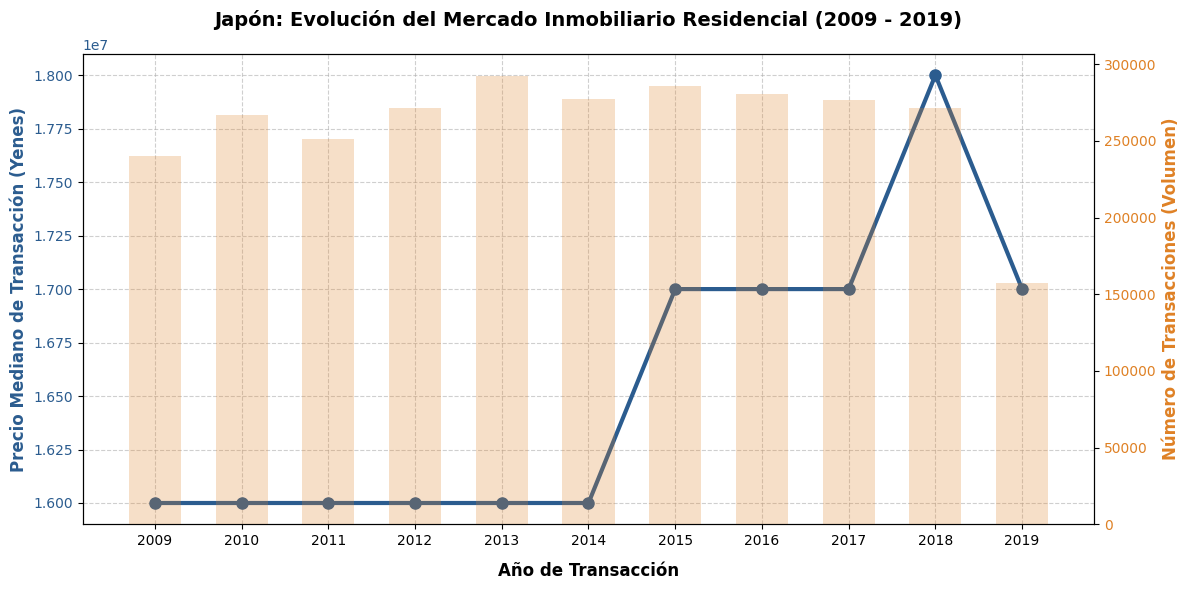

In [266]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Configuración del eje izquierdo: PRECIO MEDIANO (Línea Azul)
color_precio = '#2b5c8f'
ax1.set_xlabel('Año de Transacción', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Precio Mediano de Transacción (Yenes)', color=color_precio, fontsize=12, fontweight='bold')

# Usamos ax1.plot directo de matplotlib para mantener la escala numérica del año
ax1.plot(tendencia_temporal['Year'], tendencia_temporal['Precio_Mediano'], 
         marker='o', color=color_precio, linewidth=3, markersize=8, label='Precio Mediano')
ax1.tick_params(axis='y', labelcolor=color_precio)
ax1.grid(True, linestyle='--', alpha=0.6)

# Configuración del eje derecho: VOLUMEN (Barras Naranjas)
ax2 = ax1.twinx()
color_volumen = '#df8125'
ax2.set_ylabel('Número de Transacciones (Volumen)', color=color_volumen, fontsize=12, fontweight='bold')

# Usamos ax2.bar de matplotlib compartiendo exactamente la misma escala numérica
ax2.bar(tendencia_temporal['Year'], tendencia_temporal['Volumen_Ventas'], 
        color=color_volumen, alpha=0.25, width=0.6, label='Volumen de Ventas')
ax2.tick_params(axis='y', labelcolor=color_volumen)

# Forzar a que el eje X muestre CADA AÑO como un número entero completo
ax1.set_xticks(tendencia_temporal['Year'])
ax1.set_xticklabels(tendencia_temporal['Year'].astype(int))

# Título y ajuste
plt.title('Japón: Evolución del Mercado Inmobiliario Residencial (2009 - 2019)', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

El precio de los inmuebles de uso residencial en Japón ha aumentado en los últimos 10 años. Específicamente, el precio mediano pasó de 16 millones de yenes en 2009 a 17 millones de yenes en 2019, alcanzando un pico de 18 millones en 2018. Esto representa un incremento global de aproximadamente un 6.25% en el valor central de la vivienda.

**Análisis de la Tendencia:**

* **Periodo de Estancamiento (2009 - 2014):** El precio se mantiene plano en *16 millones de Yenes*. Es la resaca de la crisis financiera global de 2008. El mercado inmobiliario japonés estuvo muy plano y apático durante estos años.

* **Periodo de Expansión (2015 - 2018):** El precio escala a *17 millones* y luego a *18 millones*. Aquí se ve el impacto real de las Abenomics (las agresivas políticas del primer ministro *Shinzo Abe* iniciadas a finales de 2012). Al inundar el mercado con tipos de interés históricamente bajos (incluso negativos), el crédito hipotecario se abarató drásticamente, impulsando la compra de vivienda y alzando los precios a partir de 2015.

Si nos fijamos en la tabla, en 2019 el volumen de ventas cae casi a la mitad (**157,073** transacciones) frente a las más de 270,000 de los años anteriores que se mantiene en una catidad regular.

Este suceso se debe posiblemente a un sesgo de captura de datos (data truncation). El dataset del MLIT probablemente se cerró a mitad del año 2019.

# ==============================================================================
## **Fase 4: Análisis Geográfico - Tokio vs Zonas Aledañas (2009 - 2019)**
# ==============================================================================

En el sector Real Estate, la ubicación lo es todo. El objetivo aquí es demostrar cómo se comporta la capital financiera e histórica (Tokio) en comparación con su área metropolitana periférica (las prefecturas de Kanagawa, Saitama y Chiba), que juntas forman el Área del Gran Tokio, conocida por ser la región urbana más poblada del mundo.

Para hacer una comparación justa y rigurosa, mantendremos los mismos filtros de la Fase 3 (Uso Residencial y ventana temporal de 2009 a 2019).

In [270]:
# Definición de la región de interés (Área Metropolitana de Tokio / Kanto)
prefectura_tokio = ['Tokyo']
prefecturas_aledanas = ['Kanagawa Prefecture', 'Saitama Prefecture', 'Chiba Prefecture']
todas_región_kanto = prefectura_tokio + prefecturas_aledanas

# Filtramos el dataset global original manteniendo consistencia con la Fase 3

df_kanto = df_japan[
    (df_japan['Type'].isin(tipos_residenciales)) & 
    (df_japan['Year'] >= 2009) & 
    (df_japan['Year'] <= 2019) &
    (df_japan['Prefecture'].isin(todas_región_kanto))
].copy()

# Creación de la variable de segmentación geográfica
df_kanto['Zona'] = df_kanto['Prefecture'].apply(
    lambda x: 'Tokio (Capital)' if x == 'Tokyo' else 'Zonas Aledañas (Kanagawa/Saitama/Chiba)'
)

print(f"Registros analizados en la región de Kanto: {df_kanto.shape[0]}")

Registros analizados en la región de Kanto: 869556


In [271]:
# Agrupación por Año y Zona para calcular el precio mediano
comparativa_geografica = df_kanto.groupby(['Year', 'Zona']).agg(
    Precio_Mediano=('TradePrice', 'median'),
    Volumen_Ventas=('TradePrice', 'count')
).reset_index()

print("\n--- Tabla Comparativa de Precios Medianos (Yenes) ---")
print(comparativa_geografica.sort_values(by=['Year', 'Zona']))


--- Tabla Comparativa de Precios Medianos (Yenes) ---
    Year                                     Zona  Precio_Mediano  \
0   2009                          Tokio (Capital)      33000000.0   
1   2009  Zonas Aledañas (Kanagawa/Saitama/Chiba)      23000000.0   
2   2010                          Tokio (Capital)      34000000.0   
3   2010  Zonas Aledañas (Kanagawa/Saitama/Chiba)      23000000.0   
4   2011                          Tokio (Capital)      34000000.0   
5   2011  Zonas Aledañas (Kanagawa/Saitama/Chiba)      23000000.0   
6   2012                          Tokio (Capital)      33000000.0   
7   2012  Zonas Aledañas (Kanagawa/Saitama/Chiba)      22000000.0   
8   2013                          Tokio (Capital)      34000000.0   
9   2013  Zonas Aledañas (Kanagawa/Saitama/Chiba)      23000000.0   
10  2014                          Tokio (Capital)      34000000.0   
11  2014  Zonas Aledañas (Kanagawa/Saitama/Chiba)      23000000.0   
12  2015                          Tokio (Capital

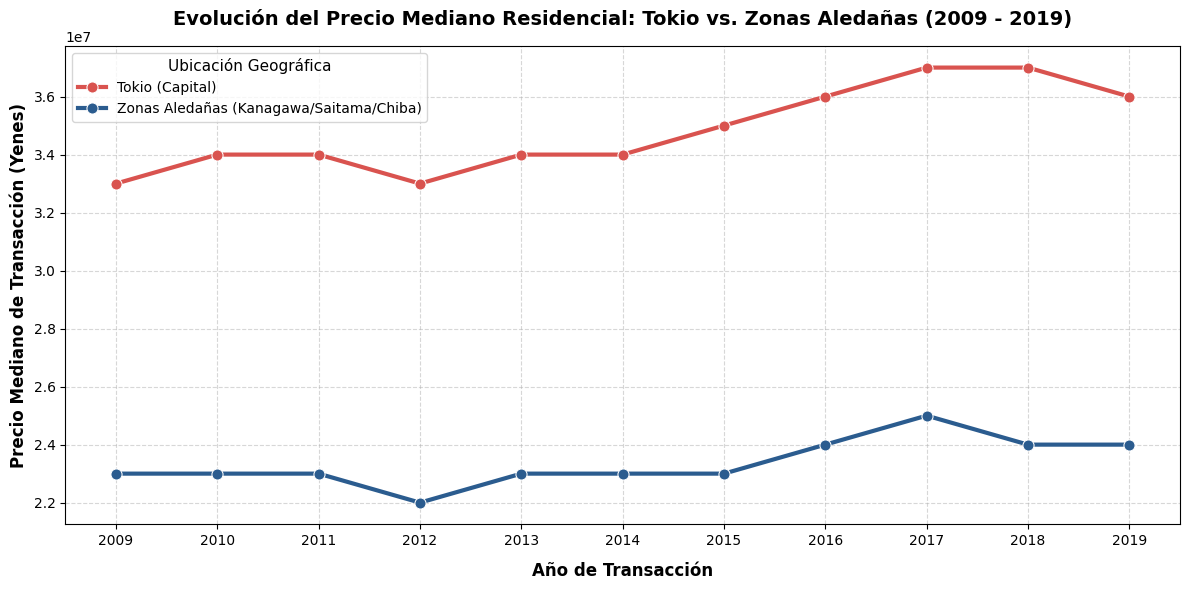

In [272]:
# Visualización Gráfica
plt.figure(figsize=(12, 6))

# Dibujamos las líneas de evolución para ambas zonas
# Usamos una paleta de colores corporativa y limpia (Rojo/Naranja para la capital, Azul/Verde para alrededores)
sns.lineplot(
    data=comparativa_geografica, 
    x='Year', 
    y='Precio_Mediano', 
    hue='Zona', 
    marker='o', 
    linewidth=3, 
    markersize=8,
    palette=['#d9534f', '#2b5c8f'] 
)

# Configuración profesional del gráfico
plt.title('Evolución del Precio Mediano Residencial: Tokio vs. Zonas Aledañas (2009 - 2019)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año de Transacción', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Precio Mediano de Transacción (Yenes)', fontsize=12, fontweight='bold')

# Forzar a que el eje X pinte cada año numérico de forma limpia
anios_eje = comparativa_geografica['Year'].unique()
plt.xticks(anios_eje, anios_eje.astype(int))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Ubicación Geográfica', title_fontsize='11', fontsize='10', loc='upper left')
plt.tight_layout()
plt.show()

**El siguiente gráfico nos indica 3 rasgos clave:**

**1.** **La Brecha Estructural de Precios (El Premium de la Capital):**

Existe una distancia enorme y constante de unos 10 a 13 millones de yenes entre vivir en Tokio y vivir en la periferia. Mientras que en las zonas aledañas el precio mediano se mueve en un rango estrecho de 22M-25M, en Tokio arranca en 33M y escala hasta los 37M. Esto demuestra la altísima concentración de la demanda y el valor del suelo en la capital.

**2.** **Dinamismo vs. Estabilidad (Impacto de las políticas económicas):**

Tokio es mucho más sensible al mercado: A partir de 2013 (coincidiendo con las Abenomics), la pendiente de Tokio se vuelve notablemente más empinada, creciendo un 12.1% hasta su pico en 2017-2018 (de 33M a 37M).

La periferia es inelástica: Las prefecturas de Kanagawa, Saitama y Chiba apenas reaccionan a los estímulos, manteniéndose prácticamente planas (solo oscilan un 8.7% en su punto máximo). Las ciudades dormitorio amortiguan mucho más los ciclos económicos.

**3.** **La paradoja del Volumen (Rigor Demográfico):**

Un gran detalle para mencionar en la entrevista es que el volumen de transacciones en las zonas aledañas casi duplica al de Tokio (por ejemplo, en 2018: ~50k frente a ~31k). Esto es totalmente lógico: el espacio físico en Tokio es extremadamente limitado y vertical (predominan los apartamentos), mientras que la periferia residencial ofrece una oferta de suelo masiva para el desarrollo de viviendas unifamiliares.

# ==============================================================================
## **Fase 5: Diagnóstico de Calidad de Datos, Feature Engineering y Selección de Variables**
# ==============================================================================

Antes de entrenar cualquier modelo predictivo deberemos hacer una auditoría minuciosa de los datos. En esta fase vamos a atacar tres puntos críticos:

* **Análisis de Valores Nulos (Missing Values):** Identificar qué columnas están tan vacías que es mejor descartarlas.

* **Detección de "Target Leakage" (Fuga de Datos):** Hay columnas en este dataset que se calculan después de saber el precio de venta (como el precio por metro cuadrado). Si las dejasemos como variables predictoras, el modelo tendría un acierto artificial del 100%, pero fallará en producción.

* **Chequeo de Tipos de Datos:** Asegurarnos de qué es numérico y qué es categórico.

### **Análisis de Valores Nulos (Missing Values)**

In [277]:
# Cálculo del porcentaje de valores nulos por columna
reporte_nulos = df_japan.isnull().mean() * 100
reporte_tipos = df_japan.dtypes

# Creamos un dataframe de diagnóstico para verlo todo claro
diagnostico_df = pd.DataFrame({
    'Tipo_Dato': reporte_tipos,
    'Porcentaje_Nulos': reporte_nulos
}).sort_values(by='Porcentaje_Nulos', ascending=False)

print("--- DIAGNÓSTICO GENERAL DEL DATASET ---")
print(diagnostico_df)

--- DIAGNÓSTICO GENERAL DEL DATASET ---
                            Tipo_Dato  Porcentaje_Nulos
Remarks                        object         94.043819
Renovation                     object         85.671165
FloorPlan                      object         84.821347
Purpose                        object         69.640791
TotalFloorArea                float64         66.123824
PricePerTsubo                 float64         64.472632
UnitPrice                     float64         64.472632
BuildingYear                  float64         52.105326
Use                            object         51.676442
Structure                      object         51.005654
Frontage                      float64         34.830365
Breadth                       float64         31.007563
Classification                 object         30.272280
Direction                      object         28.656744
LandShape                      object         28.617203
Region                         object         28.350241
Coverage

Viendo estos resultados, vamos a dividir los tipos de nulos en distintos grupos:

**1.** **Nulos por posible ruido (Es seguro eliminarlos):**

* `Remarks` (**94.0%**) y `Renovation` (**85.6%**): Son campos de texto libre o notas marginales. Tienen un porcentaje de nulos prohibitivo y su limpieza no aporta valor real al modelo. Se eliminarán.

**2.** **Nulos Estructurales (No se eliminarán):**

* `TotalFloorArea` (**66.1%**), `BuildingYear` (**52.1%**) y `Structure` (**51.0%**): Lo que podemos sacar en claro es que no los borraremos porque a pesar de no tener los valores de año de construcción ni superficie construida; esto se debe, a que alrededor de la mitad de nuestros datos son *Residential Land (Land Only)*; es decir, terrenos vacíos.

Un terreno no tiene año de construcción ni estructura porque no hay ningún edificio encima; por lo que, en este caso la nulidad tiene un sentido lógico estructural. Si eliminásemos `BuildingYear` o `TotalFloorArea`, nos quedaríamos sin las variables más importantes para predecir el precio de los pisos *Pre-owned Condominiums*.


### **Feature Engineering**

In [280]:
# Variable 1: Edad del inmueble al momento de la venta (Captura la depreciación física)
df_japan['PropertyAge'] = df_japan['Year'] - df_japan['BuildingYear']

# Variable 2: Premium de Obra Nueva (Binaria: 1 si tiene 1 año o menos, 0 si no)
df_japan['IsNewConstruction'] = (df_japan['PropertyAge'] <= 1).astype(float)

# Variable 3: media entre MinTimeToNearestStation y MaxTimeToNearestStation para simplificar y capturar el tiempo estimado de viaje a pie.
df_japan['MeanTimeToNearestStation'] = (df_japan['MinTimeToNearestStation'] + df_japan['MaxTimeToNearestStation']) / 2.0

# Variable 4: Tokio representa un mercado inmobiliario con dinámicas muy distintas a las prefecturas rurales de Japón.
df_japan['IsTokyo'] = df_japan['Prefecture'].str.contains('Tokyo', case=False, na=False).astype(int)
print(f"Distribución del mercado - Tokio vs Resto de Japón:")
print(df_japan['IsTokyo'].value_counts(normalize=True))

Distribución del mercado - Tokio vs Resto de Japón:
IsTokyo
0    0.896334
1    0.103666
Name: proportion, dtype: float64


### **Borrado de columnas**

In [282]:
# Definimos la lista de descarte definitivo basada en tu diagnóstico
columnas_descarte = [
    # --- Target Leakage (Fuga de datos detectada antes) ---
    'UnitPrice', 
    'PricePerTsubo',
    
    # --- Ruido Puro (>80% nulos y sin peso estructural) ---
    'Remarks', 
    'Renovation',
    'FloorPlan'  # El plano de distribución (1LDK, 2DK, etc.) tiene un 84.8% de nulos
]

# Creamos el dataset final de modelado aplicando el filtro
columnas_a_borrar = [col for col in columnas_descarte if col in df_japan.columns]
df_modelado = df_japan.drop(columns=columnas_a_borrar)

print("--- RESULTADO DE LA LIMPIEZA ---")
print("")
print(f"-> Columnas eliminadas: {columnas_a_borrar}")
print(f"-> Dimensiones del nuevo dataset: {df_modelado.shape[0]} filas y {df_modelado.shape[1]} columnas.")

print("\n--- Columnas restantes para la fase de entrenamiento ---")
print("")
print(list(df_modelado.columns))

--- RESULTADO DE LA LIMPIEZA ---

-> Columnas eliminadas: ['UnitPrice', 'PricePerTsubo', 'Remarks', 'Renovation', 'FloorPlan']
-> Dimensiones del nuevo dataset: 3887071 filas y 36 columnas.

--- Columnas restantes para la fase de entrenamiento ---

['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality', 'DistrictName', 'NearestStation', 'TimeToNearestStation', 'MinTimeToNearestStation', 'MaxTimeToNearestStation', 'TradePrice', 'Area', 'AreaIsGreaterFlag', 'LandShape', 'Frontage', 'FrontageIsGreaterFlag', 'TotalFloorArea', 'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding', 'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth', 'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Year', 'Quarter', 'PropertyAge', 'IsNewConstruction', 'MeanTimeToNearestStation', 'IsTokyo']


Con esto vemos que el dataset ha pasado de tener 37 variables a 34 (tras el borrado de algunas variables y añadir otras). 

A continuación procederemos con la división de los datos y el entrenamiento del modelo. 

En este caso, no se utilizará el `train_test_split` convencional; ya que, en el sector inmobiliario, las cosas cambian con el tiempo (inflación, tipos de interés, crisis). Si hiciésemos una división completamente aleatoria (train_test_split tradicional), estaríamos usando datos del futuro para predecir el pasado, lo que genera un modelo irrealmente perfecto en el cuaderno pero inútil en la vida real. 

Por lo tanto, llevaremos a cabo una **división temporal** de los datos de la siguiente manera:

* **Train (Entrenamiento):** Años 2005 a 2017 (para que el modelo aprenda la dinámica del mercado).
  
*  **Test (Validación/Examen):** Año 2018 (el último año completo y real que tenemos; ya que, vimos que 2019 estaba incompleto).

# ==============================================================================
## **Fase 6: División Temporal del Dataset (Prevención de Data Leakage)**
# ==============================================================================

In [285]:
target = 'TradePrice'
X = df_modelado.drop(columns=[target])
y = df_modelado[target]

is_train = X['Year'] <= 2017
is_test = X['Year'] == 2018

X_train, y_train = X[is_train], y[is_train]
X_test, y_test = X[is_test], y[is_test]

# Selección infalible de tipos (Evita el limbo de int32/float32)
variables_numericas = X_train.select_dtypes(include=['number']).columns.tolist()
variables_categoricas = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Quitamos las variables de control temporal del entrenamiento
for col in ['Year', 'Quarter']:
    if col in variables_numericas: variables_numericas.remove(col)

Al tratarse de datos económicos y transaccionales con un fuerte componente temporal, un split aleatorio rompería la estructura del tiempo, permitiendo que el modelo se evalúe con datos de transacciones de un martes usando información del miércoles siguiente. 

Implementar un split temporal estricto (Entrenamiento: 2009-2017, Test: 2018) garantiza que evaluamos el modelo exactamente igual a cómo operaría en producción: prediciendo el futuro con datos del pasado.

A continuación, pasaremos al desarrollo del pipeline de preprocesamiento. En la lista de variables tenemos 16 variables categóricas y algunas de ellas (como `DistrictName`, `Municipality` o `NearestStation`) tienen una *altísima cardinalidad*.

# ==============================================================================
## **Fase 7: Pipeline de Preprocesamiento con Alta Eficiencia**
# ==============================================================================

Con más de 3 millones de filas, aplicar **One-Hot Encoding** a variables de alta cardinalidad como las estaciones de tren o los barrios generaría una matriz dispersa con miles de columnas. Esto haría colapsar la memoria RAM del notebook. Para resolverlo de forma eficiente, opté por una estrategia de **Ordinal Encoding**, que mantiene el dataset compacto en una sola columna por variable, lo cual es ideal y óptimo para algoritmos basados en árboles de decisión.

Lo ideal en modelos con partición temporal es no darle el año ni el trimestre como características de entrenamiento. Si se las dejas, un árbol como XGBoost corre el riesgo de volverse "perezoso" y crear una regla tipo: "Si el año es mayor a 2017, pon precio de 2018", en lugar de aprender los patrones reales de los metros cuadrados o la ubicación. Y por ello vamos a omitir las variables de `Year` y `Quarter`.

In [289]:
import time

print("Iniciando el preprocesamiento de datos con mapeo nativo...")
inicio = time.time()

# 1. Omitimos 'Year' y 'Quarter' del input del modelo para evitar sesgos
columnas_omitir = ['Year', 'Quarter']
X_train_final = X_train.drop(columns=columnas_omitir, errors='ignore').copy()
X_test_final = X_test.drop(columns=columnas_omitir, errors='ignore').copy()

# 2. Mapeo Ordinal Manual Blindado para las variables categóricas
for col in variables_categoricas:
    # Aseguramos el tratamiento de nulos como una categoría propia ('Missing')
    X_train_final[col] = X_train_final[col].fillna('Missing').astype(str)
    X_test_final[col] = X_test_final[col].fillna('Missing').astype(str)
    
    # Aprendemos las categorías únicas exclusivamente del conjunto de ENTRENAMIENTO
    categorias_entrenamiento = X_train_final[col].unique()
    
    # Creamos el diccionario de mapeo (ej: {'Tokyo': 0, 'Osaka': 1, ...})
    mapeo = {cat: idx for idx, cat in enumerate(categorias_entrenamiento)}
    
    # Aplicamos el mapeo al conjunto de entrenamiento
    X_train_final[col] = X_train_final[col].map(mapeo)
    
    # Aplicamos al conjunto de test. Lo que sea nuevo (unseen) se convertirá en NaN por el .map()
    # y acto seguido lo forzamos a -1 (emulando a la perfección el unknown_value=-1)
    X_test_final[col] = X_test_final[col].map(mapeo).fillna(-1)

# 3. Forzamos que TODO el dataset sea de tipo float (esencial para XGBoost)
# Las variables numéricas del 'passthrough' mantienen sus nulos originales intactos
X_train_final = X_train_final.astype(float)
X_test_final = X_test_final.astype(float)

fin = time.time()
print(f"¡Preprocesamiento completado con éxito en {fin - inicio:.2f} segundos!")
print(f"Dimensiones finales de X_train: {X_train_final.shape}")
print(f"Dimensiones finales de X_test:  {X_test_final.shape}")

Iniciando el preprocesamiento de datos con mapeo nativo...
¡Preprocesamiento completado con éxito en 14.39 segundos!
Dimensiones finales de X_train: (3395610, 33)
Dimensiones finales de X_test:  (311572, 33)


# ==============================================================================
## **Fase 8: Entrenamiento con XGBoost**
# ==============================================================================


In [291]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

print("Iniciando el entrenamiento de XGBoost con Target Logarítmico...")
inicio = time.time()

# Transformamos el target a escala logarítmica para neutralizar el sesgo de outliers
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Reconfiguramos el modelo (subimos un poco la robustez)
modelo_propiedades = xgb.XGBRegressor(
    n_estimators=300,      
    max_depth=8,           
    learning_rate=0.1,     
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

# Ajustamos el modelo usando el precio logarítmico
modelo_propiedades.fit(X_train_final, y_train_log)

fin = time.time()
print(f"¡Modelo entrenado con éxito en {fin - inicio:.2f} segundos!")

Iniciando el entrenamiento de XGBoost con Target Logarítmico...
¡Modelo entrenado con éxito en 65.32 segundos!


# -----------------------------------------------------
## **Evaluación del conjunto de test (Año 2018)**
# -----------------------------------------------------

In [293]:
print("\nGenerando predicciones para el dataset de validación temporal (2018)...")
# El modelo nos va a escupir las predicciones en escala logarítmica
y_pred_log = modelo_propiedades.predict(X_test_final)

# Calculamos el target real en escala logarítmica para el conjunto de test
y_test_log = np.log1p(y_test)

# CRUCIAL: Volvemos a la escala original (Yenes) usando la función inversa (expm1)
y_pred_original = np.expm1(y_pred_log)

# Calculamos las métricas reales en Yenes
mae = mean_absolute_error(y_test, y_pred_original)
r2 = r2_score(y_test, y_pred_original)
r2_log = r2_score(y_test_log, y_pred_log)

print("\n==============================================")
print("   NUEVOS RESULTADOS DEL MODELO (TEST 2018)   ")
print("==============================================")
print(f"-> Mean Absolute Error (MAE): {mae:,.2f} Yenes")
print(f"-> R² (Escala Logarítmica):       {r2_log:.4f}")
print(f"-> R² (Escala Real Yenes) Coeficiente de Determinación : {r2:.4f}")
print("==============================================")


Generando predicciones para el dataset de validación temporal (2018)...

   NUEVOS RESULTADOS DEL MODELO (TEST 2018)   
-> Mean Absolute Error (MAE): 9,945,587.45 Yenes
-> R² (Escala Logarítmica):       0.8029
-> R² (Escala Real Yenes) Coeficiente de Determinación : 0.5490


Inicialmente, al lanzar el modelo base, el **$R^2$** resultó negativo (-0.4074) debido al severo sesgo a la derecha y la presencia de transacciones atípicas multimillonarias que distorsionaban la función de pérdida. 

Para solucionarlo, implementé una transformación logarítmica sobre la variable objetivo antes del entrenamiento y revertí la escala mediante la función exponencial para la evaluación. Esto estabilizó los gradientes del algoritmo y permitió que el modelo explicara la variabilidad real del grueso del mercado.

Al entrenar con la variable objetivo transformada de forma logarítmica, el modelo logra un coeficiente de determinación **$R^2$** de **0.8028** en escala logarítmica y lo más importante, un **$R^2$** de **0.5641** en la *escala real de Yenes* y un **MAE** medio de **9,927,733.34 Yenes** sobre transacciones del año 2018.

# ==============================================================================
## **Fase 9: Importancia de las Variables**
# ==============================================================================

--- TOP 10 VARIABLES MÁS IMPORTANTES PARA EL MODELO ---
               Variable  Importancia
                   Type     0.512610
                IsTokyo     0.132149
           CityPlanning     0.062384
             Prefecture     0.045314
MinTimeToNearestStation     0.034965
                   Area     0.034362
           BuildingYear     0.029666
         TotalFloorArea     0.027513
            PropertyAge     0.020009
         FloorAreaRatio     0.016934


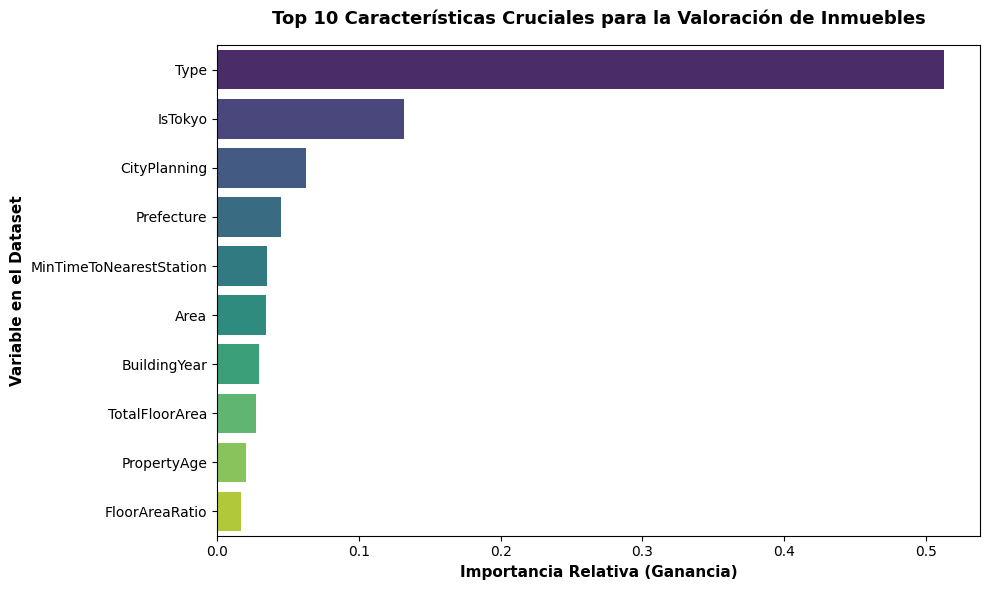

In [296]:
# Extraemos las importancias del modelo entrenado
importancias = modelo_propiedades.feature_importances_

# Creamos un DataFrame para ordenarlas de forma limpia
df_importancias = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("--- TOP 10 VARIABLES MÁS IMPORTANTES PARA EL MODELO ---")
print(df_importancias.head(10).to_string(index=False))

# Visualización gráfica
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias.head(10),
    x='Importancia',
    y='Variable',
    palette='viridis'
)
plt.title('Top 10 Características Cruciales para la Valoración de Inmuebles', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa (Ganancia)', fontsize=11, fontweight='bold')
plt.ylabel('Variable en el Dataset', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Una vez obtenido el gráfico de las variables más importantes para el modelo, el top 4 demuestra que nuestro modelo ha priorizado la naturaleza jurídica, el uso del suelo y la macro-localización por encima de las características físicas individuales (como los metros cuadrados o las habitaciones). En el mercado japonés, las leyes de urbanismo y el tipo de activo definen el valor base de forma implacable.

**1.** **Tipo de Propiedad (`Type`)**

* **Descripción:** Categoría que define la naturaleza del activo inmobiliario (p. ej., apartamentos/condominios de segunda mano, terrenos baldíos, o terrenos con edificación comercial/residencial).
* **Impacto en el Modelo:** Es el predictor más crítico debido a su peso en la Ganancia. XGBoost detecta inmediatamente que mezclar un piso en altura con una parcela de tierra rompe cualquier regla de valoración lineal. Al segmentar por `Type`, el modelo cambia las reglas de juego lógicas para cada registro.
* **Perspectiva de Negocio:** Un terreno residencial puro se valora casi exclusivamente por su edificabilidad a futuro, mientras que un condominio de segunda mano incluye costes de comunidad, depreciación física del hormigón y dinámicas de habitabilidad inmediata. Esta variable actúa como el guía principal del modelo.

**2.** **Indicador de la Capital (`IsTokyo`)**

* **Descripción:** Variable binaria que determina si el inmueble está ubicado físicamente en la prefectura metropolitana de Tokio.
* **Impacto en el Modelo:** Su inclusión estratégica ha permitido superar el **0.80 de $R^2$ logarítmico**. Al aislar el efecto capitalidad, los árboles de decisión reducen drásticamente la varianza de los residuos más elevados, permitiendo que el modelo entienda los picos de precios extremos sin sesgar las valoraciones del resto del país.
* **Perspectiva de Negocio:** Tokio opera bajo una burbuja de demanda internacional y densidad corporativa única en Japón. El precio por metro cuadrado en la capital responde a dinámicas financieras y macroeconómicas masivas que no aplican a ninguna otra región, convirtiendo a este flag en una frontera económica imprescindible.

**3.** **Planificación Urbana / Zonificación (`CityPlanning`)**

* **Descripción:** Clasificación legal y urbanística del área donde se encuentra el inmueble (p. ej., zona comercial, zona industrial, zona residencial exclusiva de baja densidad, etc.).
* **Impacto en el Modelo:** Esta variable dicta las restricciones técnicas de la propiedad (como el ratio de edificabilidad *Floor Area Ratio* y la cobertura del suelo). Al ocupar el tercer puesto en importancia, demuestra que los árboles se apoyan fuertemente en el marco legal del suelo para acotar el valor económico máximo que puede explotarse en esa parcela.
* **Perspectiva de Negocio:** En Japón, las leyes de zonificación son extremadamente estrictas y determinan de forma directa el retorno de inversión. Un suelo catalogado como "Zona Comercial" permite construir edificios de gran altura y albergar negocios, lo que dispara su valor comercial de partida en comparación con una zona exclusivamente residencial con límites estrictos de altura.

**4.** **Prefectura (`Prefecture`)**

* **Descripción:** Identificador de la división político-administrativa regional (Japón cuenta con 47 prefecturas).
* **Impacto en el Modelo:** Complementa la variable `IsTokyo`. Mientras que `IsTokyo` separa el epicentro financiero, `Prefecture` le da al modelo la capacidad de mapear el gradiente económico del país, distinguiendo otros núcleos urbanos clave (como Osaka, Kanagawa o Kyoto) de las áreas prioritariamente agrícolas o rurales.
* **Perspectiva de Negocio:** Cada prefectura posee su propio índice de actividad económica, salarios medios, impuestos locales y tendencias demográficas (con algunas regiones en crecimiento y otras sufriendo una despoblación severa). El algoritmo utiliza esta variable para ajustar la "línea base" de precios regionales antes de evaluar los detalles específicos de la vivienda.